<a href="https://colab.research.google.com/github/PelemisMilica/dogs-classification-pppo/blob/main/Dogs_Classification_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Principi prezentacije i prepoznavanje oblika (IIS 2024/2025)**

**Autor:** Milica Pelemiš, IT61-2021

**Opis zadatka:** Klasifikacija slika pasa

**GitHub link:** https://github.com/PelemisMilica/dogs-classification-pppo


#SADRŽAJ

1. Uvod
2. Teorijski dio
3. Analiza dataset-a
4. Praktični dio
5. Zaključak
6. Literatura



#UVOD

Klasifikacija slika predstavlja važan zadatak u računarskom vidu, gdje je cilj automatski prepoznati kojoj kategoriji pripada sadržaj na fotografiji. U praksi se koristi za organizaciju i pretragu velikih kolekcija slika, identifikaciju objekata u realnom okruženju i podršku različitim automatizovanim sistemima. Posebnu težinu ovim problemima daju varijacije u osvjetljenju, pozadini, udaljenosti i uglu snimanja, zbog čega isti objekat može izgledati značajno različito na različitim fotografijama.

U ovom projektu rješava se zadatak klasifikacije rasa pasa na osnovu fotografija. Zadatak je višeklasna klasifikacija (`multi-class`), jer svaka slika pripada tačno jednoj rasi. Dataset je organizovan kroz folder sa trening slikama (`train/`) i folder sa test slikama (`test/`), dok fajl `labels.csv` sadrži mapiranje između identifikatora slike i naziva rase. Takođe je obezbijeđen **sample_submission.csv** koji definiše format predaje rezultata za test skup.

S obzirom na to da dataset sadrži 120 klasa, kao i da se mnoge rase vizuelno preklapaju (slična boja dlake, građa i proporcije), problem je zahtjevan. Fotografije dodatno variraju po kvalitetu i uslovima snimanja, pa je cilj izgraditi model koji generalizuje i daje dobre rezultate na novim slikama, a ne samo na trening primjerima.

U nastavku rada prikazani su koraci pripreme i učitavanja podataka, formiranja **tf.data pipeline-a**, definisanja i treniranja modela, evaluacije na validacionom skupu, kao i generisanja `submission.csv` fajla sa predikcijama za test skup.

#TEORIJSKI DIO

Klasifikacija slika je zadatak mašinskog učenja u kojem se, na osnovu ulazne fotografije, određuje kojoj klasi ona pripada. Kod višeklasne klasifikacije (`multi-class`) pretpostavlja se da svaki primjer pripada tačno jednoj klasi, pa model na izlazu vraća vjerovatnoće za sve klase, a kao konačan rezultat bira se ona sa najvećom vjerovatnoćom. Suština problema je u tome da slike nose mnogo različitih informacija istovremeno — boje, teksture, oblike, pozadinu i osvjetljenje — pa je potrebno pronaći reprezentaciju koja izdvaja ono što je “bitno” za razliku između klasa, a zanemaruje nebitne varijacije.

U praksi se za ovakve zadatke najčešće koriste konvolucione neuronske mreže (CNN), jer su posebno prilagođene radu sa slikama. Konvolucioni slojevi uče filtere koji prepoznaju lokalne obrasce u slici. U ranim slojevima mreža najčešće uči jednostavne karakteristike, poput ivica i osnovnih tekstura, dok se kroz dublje slojeve te informacije kombinuju u sve složenije vizuelne “pojmove”. Na taj način, CNN modeli automatski uče korisne karakteristike direktno iz podataka, bez potrebe da se one ručno definišu, što je jedna od najvećih prednosti u odnosu na klasične pristupe.

Ipak, treniranje dubokih CNN arhitektura od nule obično zahtijeva mnogo podataka i vremena, kao i značajne računarske resurse. Zbog toga je u savremenim rješenjima vrlo čest `transfer learning` pristup, gdje se kao početna tačka uzima model koji je već treniran na velikom i raznovrsnom skupu slika (najčešće `ImageNet`). Ideja je da takav model već sadrži “opšte” vizuelne reprezentacije koje su korisne u širokom spektru zadataka, pa se za novi problem ne kreće od početka, već se postojeće znanje prilagođava novim klasama.

`Transfer learning` se najčešće realizuje u dvije faze. U prvoj fazi bazni dio mreže (`feature extractor`) se zamrzava, što znači da se njegove težine ne mijenjaju, dok se trenira samo završni dio mreže koji je dodan za konkretnu klasifikaciju. Ova faza je stabilna i brža, jer model koristi već naučene reprezentacije. Nakon toga se može primijeniti `fine-tuning`, gdje se otključava dio slojeva baznog modela i treniranje se nastavlja manjom stopom učenja (learning rate). Fine-tuning omogućava da se reprezentacije dodatno prilagode konkretnom domenu, ali uz kontrolisan tempo promjena, kako ne bi došlo do gubitka prethodno naučenih korisnih osobina.

Da bi se model mogao trenirati, slike moraju biti pripremljene u standardizovanom formatu. Uobičajeni koraci uključuju promjenu dimenzija (resize) na fiksnu veličinu ulaza, konverziju u numerički format i normalizaciju vrijednosti piksela, što stabilizuje učenje. Pored toga, zbog efikasnosti se često koristi pipeline za učitavanje podataka koji podržava batching i prefetching, čime se smanjuje vrijeme čekanja na podatke tokom treniranja i bolje koristi dostupni hardver.

Važan element koji dodatno poboljšava generalizaciju modela je augmentacija podataka. Ona podrazumijeva kontrolisane transformacije slika (npr. horizontalni flip, blaga rotacija, promjena skale), pri čemu se transformacije primjenjuju samo na trening skup. Cilj augmentacije nije da se “promijeni značenje” slike, već da se model navikne na realne varijacije koje se mogu pojaviti u praksi. Time se smanjuje rizik da model nauči specifičnosti trening skupa i povećava se otpornost na promjene u ulazu.

Performanse modela procjenjuju se kroz odgovarajuće metrike. Kada su labele kodirane kao numerički indeksi, prirodan izbor funkcije greške je `sparse categorical crossentropy`, dok se kao osnovna metrika često koristi `accuracy`, koja pokazuje procenat tačno klasifikovanih primjera. Međutim, kod problema sa većim brojem klasa, korisno je analizirati rezultate detaljnije, jer prosječna accuracy vrijednost može prikriti loše performanse na pojedinim klasama. Zbog toga se često posmatraju precision, recall i F1-score po klasama (kroz `classification report`), kao i matrica konfuzije koja jasno pokazuje koje se klase najčešće međusobno miješaju.

Kako bi trening bio stabilniji i da bi se smanjila mogućnost pretreniranosti (overfitting), koriste se i tehnike regularizacije i kontrole učenja. Dropout, na primjer, tokom treniranja nasumično “isključuje” dio neurona i na taj način smanjuje zavisnost mreže od pojedinačnih karakteristika. Pored toga, callback mehanizmi poput `EarlyStopping` pomažu da se trening zaustavi kada validacioni rezultat prestane da se poboljšava, dok `ReduceLROnPlateau` smanjuje learning rate kada napredak uspori, što često dovodi do finijeg poboljšanja performansi bez nepotrebno dugog treniranja.

Na ovaj način teorijski okvir obuhvata ključne koncepte potrebne za rješavanje klasifikacije slika: način na koji CNN modeli uče vizuelne reprezentacije, zašto se koristi transfer learning i fine-tuning, kako se pripremaju i augmentuju podaci, te kako se model evaluira i stabilizuje tokom treniranja.

#ANALIZA DATASET-A

Za izradu modela korišćen je dataset za klasifikaciju rasa pasa [Dog_Classification](D:\Downloads\Dog_Classification.zip).

Podaci su organizovani u dva glavna foldera:
- `train/` – slike koje se koriste za treniranje modela
- `test/` – slike bez labela koje se koriste za generisanje konačnih predikcija

Trening labele se nalaze u fajlu `labels.csv`, koji sadrži sljedeće kolone:
- **id** – identifikator slike (naziv fajla bez ekstenzije)
- **breed** – rasa psa (klasa)

Naziv slike se dobija tako što se na vrijednost **id** dodaje ekstenzija .jpg, pa se putanja do slike formira u obliku `train/id.jpg`.

Test skup ne sadrži labele. Format predaje rezultata definisan je u fajlu `sample_submission.csv`, koji sadrži:
- kolonu **id** za test slike
- po jednu kolonu za svaku rasu u dataset-u (ukupno 120 kolona)

Vrijednosti u tim kolonama predstavljaju vjerovatnoće koje model dodjeljuje pojedinim klasama.

Dataset sadrži ukupno 120 rasa, pa se radi o višeklasnoj klasifikaciji. Broj slika po klasama nije potpuno identičan, ali raspodjela nije pretjerano neuravnotežena, zbog čega nije bilo potrebe za posebnim balansiranjem podataka. Takođe, slike su snimane u različitim uslovima (različite pozadine, osvjetljenje i položaji pasa), što otežava prepoznavanje rasa i čini da model mora da nauči stabilne vizuelne karakteristike koje se mogu prepoznati i na novim primjerima.

#PRAKTIČNI DIO

#1 Učitavanje biblioteka i podešavanje okruženja
U prvom koraku praktičnog dijela projekta vrši se uvoz svih biblioteka i modula koji su potrebni za obradu podataka, pripremu skupa za treniranje, kreiranje modela i evaluaciju rezultata.

- **sys** i **platform** – koriste se za prikaz osnovnih informacija o Python okruženju i operativnom sistemu, što pomaže pri provjeri kompatibilnosti i lakšem otklanjanju grešaka.
- **os** i **pathlib.Path** – koriste se za rad sa fajl sistemom i definisanje putanja do foldera i datoteka (slike za treniranje/testiranje i CSV fajlovi).
- **random**, **numpy** i **tensorflow** – koriste se za podešavanje slučajnosti (seed vrijednosti) i izvođenje numeričkih operacija, kako bi rezultati bili što ujednačeniji pri ponovnom pokretanju notebook-a.
- **pandas** – učitavanje i obrada tabelarnih podataka iz CSV fajlova (labels.csv, sample_submission.csv).
- **matplotlib.pyplot** – vizuelni prikaz podataka i rezultata, uključujući raspodjelu klasa, prikaz primjera slika i grafike toka treniranja modela.
- **PIL** (Image) – učitavanje, otvaranje i prikaz slika iz skupa podataka tokom analize i provjere rada modela.
- **tensorflow.keras** (layers, models, applications, callbacks, optimizers) – služi za izgradnju i podešavanje modela, korišćenje prethodno treniranih mreža (transfer learning), kao i za kontrolu treniranja kroz callback funkcije.
- **sklearn.preprocessing.LabelEncoder** – pretvaranje tekstualnih naziva rasa pasa u numeričke oznake pogodne za klasifikaciju.
- **sklearn.model_selection.train_test_split** – podjela podataka na trening i validacioni skup.
- **sklearn.model_selection.StratifiedKFold** – koristi se za podjelu skupa podataka na više dijelova tako da raspodjela klasa ostane približno ista, čime evaluacija modela postaje stabilnija i realnija.
- **google.colab** - online okruženje za pokretanje Jupyter notebook-a u pregledaču. Omogućava izvršavanje Python koda bez instalacije na računaru i jednostavno korišćenje GPU-a za brže treniranje modela.

In [ ]:
import sys
import platform
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, applications, callbacks, optimizers
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from google.colab import drive

#2 Provjera okruženja i podešavanje početnih vrijednosti

Prije učitavanja podataka vrši se provjera izvršnog okruženja (verzija Pythona, operativni sistem i informacija da li se notebook pokreće u Google Colab okruženju).

Takođe se postavlja početna **seed** vrijednost radi konzistentnijeg ponašanja pri nasumičnim operacijama u daljem toku rada.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Python:", sys.version)
print("OS:", platform.platform())
print("Colab:", IN_COLAB)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS: Linux-6.6.113+-x86_64-with-glibc2.35
Colab: True


#3 Povezivanje sa Google Drive-om

U ovom koraku vrši se povezivanje Google Colab okruženja sa Google Drive-om, kako bi se omogućio pristup dataset-u i pratećim fajlovima (slike i CSV datoteke) koji su smješteni u odgovarajućem folderu na Drive-u.

Na ovaj način Colab može direktno da učitava podatke bez potrebe za ručnim upload-ovanjem fajlova pri svakom pokretanju notebook-a.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#4 Učitavanje CSV fajla i priprema putanja do slika
Nakon povezivanja sa Google Drive-om, sljedeći korak je definisanje osnovnih putanja do foldera sa slikama i CSV fajlova koji se koriste u projektu.

Definišu se putanje do:
- foldera `train` (slike za treniranje),
- foldera `test` (slike za testiranje),
- fajla `labels.csv` (oznake klasa za trening slike),
- fajla `sample_submission.csv` (šablon za formiranje rezultata predikcije).

U okviru istog koraka definišu se i nazivi kolona:
- `id` – identifikator slike,
- `breed` – naziv rase psa (klasa).

Zatim se vrši provjera da li fajl labels.csv postoji na zadatoj lokaciji, nakon čega se učitava u DataFrame (**df**) radi daljih koraka obrade i pripreme podataka.

Takođe će se izvršiti tabelarni prikaz podataka iz fajla **labels.csv**.

In [ ]:
BASE_DIR   = Path('/content/drive/MyDrive/PPPO_Dogs_Milica/Dog_Classification')
TRAIN_DIR  = BASE_DIR / 'train'
TEST_DIR   = BASE_DIR / 'test'
LABELS_CSV = BASE_DIR / 'labels.csv'
SUB_TPL    = BASE_DIR / 'sample_submission.csv'

FILENAME_COL = 'id'
LABEL_COL    = 'breed'

assert LABELS_CSV.exists(), f"Nije pronađen labels CSV: {LABELS_CSV}"
df = pd.read_csv(LABELS_CSV)
print("labels.csv shape:", df.shape)
df.head()

labels.csv shape: (10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


#5 Priprema podataka za treniranje i validaciju
Nakon učitavanja fajla `labels.csv`, u ovom koraku vrši se priprema podataka za treniranje klasifikacionog modela.

Priprema obuhvata formiranje pune putanje do svake slike, provjeru postojanja fajlova, kodiranje klasnih oznaka u numerički oblik i podjelu skupa podataka na trening i validacioni dio.

##5.1 Formiranje pune putanje do slika
U koloni `id` nalaze se identifikatori slika, pa je potrebno formirati punu putanju do svake slike u `train` folderu.

Dodavanjem ekstenzije .jpg kreira se nova kolona `filepath`, koja će se koristiti u daljem radu sa slikama.

In [ ]:
df[FILENAME_COL] = df[FILENAME_COL].astype(str)
df['filepath'] = df[FILENAME_COL].apply(lambda x: str(TRAIN_DIR / f"{x}.jpg"))

##5.2 Provjera postojanja fajlova
Prije nastavka obrade vrši se provjera da li sve formirane putanje zaista postoje.

Ovaj korak je važan kako bi se eventualne greške u strukturi foldera ili nazivima fajlova otkrile prije treniranja modela.

In [ ]:
missing = df.loc[~df['filepath'].apply(lambda p: Path(p).exists())]
if len(missing) > 0:
    print("UPOZORENJE: Neke putanje ne postoje! Prvih 5:", missing.head())
else:
    print("Sve putanje postoje.")

Sve putanje postoje.


Ako su sve putanje ispravne, može se bezbjedno nastaviti sa pripremom labela i podjelom skupa podataka.

##5.3 Label Encoding
Pošto model ne može direktno da koristi tekstualne nazive rasa pasa, vrijednosti iz kolone breed pretvaraju se u numeričke oznake pomoću `LabelEncoder` klase.

Numeričke oznake se smještaju u novu kolonu **y**, dok se originalni nazivi klasa čuvaju radi kasnije interpretacije rezultata.

Na ovaj način svaka rasa psa dobija jedinstvenu numeričku oznaku pogodnu za treniranje višeklasnog klasifikacionog modela.

In [ ]:
le = LabelEncoder()
df['y'] = le.fit_transform(df[LABEL_COL].astype(str))
class_names = le.classes_
num_classes = len(class_names)
print("Broj klasa:", num_classes)

Broj klasa: 120


##5.4 Podjela na trening i validacioni skup
U posljednjem koraku pripreme, dataset se dijeli na trening i validacioni skup u odnosu 80% : 20%.

Koristi se stratifikovana podjela (stratify) kako bi raspodjela klasa ostala što sličnija u oba skupa, što doprinosi realnijoj evaluaciji modela.

In [ ]:
train_df, val_df = train_test_split(
    df[['filepath','y']],
    test_size=0.2,
    random_state=SEED,
    stratify=df['y']
)
print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 8177
Val size: 2045


Nakon izvršavanja ovog koraka dobijeni su `train_df` i `val_df`, koji sadrže putanje do slika i numeričke oznake klasa, spremne za kreiranje `tf.data pipeline`-a.

In [ ]:
train_counts = train_df["y"].value_counts()
val_counts   = val_df["y"].value_counts()

print("Train min/max po klasi:", train_counts.min(), train_counts.max())
print("Val   min/max po klasi:", val_counts.min(), val_counts.max())

Train min/max po klasi: 53 101
Val   min/max po klasi: 13 25


#6 Analiza skupa podataka
Nakon pripreme podataka i njihove podjele na trening i validacioni skup, pristupa se osnovnoj eksplorativnoj analizi skupa podataka.

U ovom koraku analizira se raspodjela klasa, broj uzoraka po klasama i vizuelno se pregledaju reprezentativni primjeri slika iz trening skupa.

Svrha ove analize je da se stekne jasniji uvid u strukturu i karakteristike dataset-a, kao i da se procijeni da li postoji izražen disbalans klasa koji bi zahtijevao dodatne korake balansiranja prije treniranja modela.

##6.1 Osnovne informacije o trening i validacionom skupu
Najprije se ispisuju osnovne informacije o formiranim skupovima podataka, odnosno broj uzoraka u trening i validacionom skupu, kao i ukupan broj klasa koje model treba da razlikuje.

Ovaj korak omogućava brz uvid u strukturu podataka nakon izvršene podjele, te potvrđuje da su skupovi uspješno formirani i spremni za naredne faze obrade, treniranja i evaluacije modela.

In [ ]:
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Broj klasa:", num_classes)

Train size: 8177
Val size: 2045
Broj klasa: 120


Dobijeni ispis potvrđuje broj uzoraka u oba skupa i ukupan broj klasa koje model treba da razlikuje.

##6.2 Provjera raspodjele klasa
U nastavku se analizira raspodjela klasa u trening i validacionom skupu.

Cilj je da se provjeri da li su klase približno ravnomjerno zastupljene, odnosno da li postoji izražen disbalans koji bi mogao uticati na treniranje modela.

In [ ]:
train_counts = train_df["y"].value_counts()
val_counts   = val_df["y"].value_counts()

print("Train min/max po klasi:", train_counts.min(), train_counts.max())
print("Val   min/max po klasi:", val_counts.min(), val_counts.max())

Train min/max po klasi: 53 101
Val   min/max po klasi: 13 25


Na osnovu minimalnog i maksimalnog broja uzoraka po klasi može se procijeniti stepen neravnomjerne zastupljenosti klasa i eventualna potreba za balansiranjem.

##6.3 Vizuelni prikaz raspodjele klasa
Radi preglednijeg uvida u raspodjelu klasa, prikazuje se histogram najzastupljenijih rasa pasa u trening skupu.

Pošto `train_df` sadrži numeričke oznake klasa (**y**), vrši se mapiranje nazad na tekstualne nazive rasa radi lakšeg tumačenja rezultata.

Broj klasa: 120


,count
y,
scottish_deerhound,101
afghan_hound,93
maltese_dog,93
entlebucher,92
bernese_mountain_dog,91
great_pyrenees,89
pomeranian,89
shih-tzu,89
basenji,88


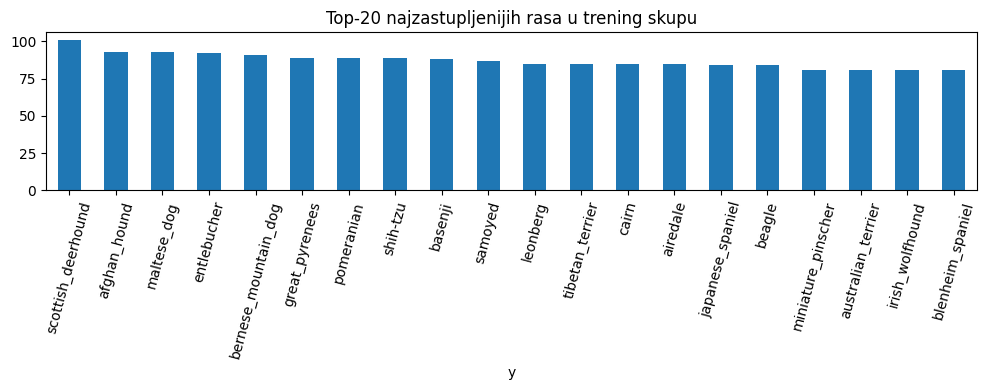

Min/Max po klasi: 53 101


In [ ]:
y_to_breed = dict(enumerate(class_names))
train_breeds = train_df["y"].map(y_to_breed)

counts = train_breeds.value_counts()

print("Broj klasa:", counts.shape[0])
display(counts.head(10))

plt.figure(figsize=(10, 4))
counts.head(20).plot(kind="bar")
plt.title("Top-20 najzastupljenijih rasa u trening skupu")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

print("Min/Max po klasi:", counts.min(), counts.max())

Grafik prikazuje najzastupljenije klase u trening skupu i omogućava vizuelnu procjenu raspodjele podataka među rasama pasa.

##6.4 Vizuelni pregled uzoraka slika iz trening skupa
Pored numeričke analize, korisno je izvršiti i vizuelni pregled dijela slika iz trening skupa.

Prikaz slučajno odabranih uzoraka omogućava uvid u raznolikost slika, kvalitet podataka i izgled klasa koje model treba da prepoznaje.

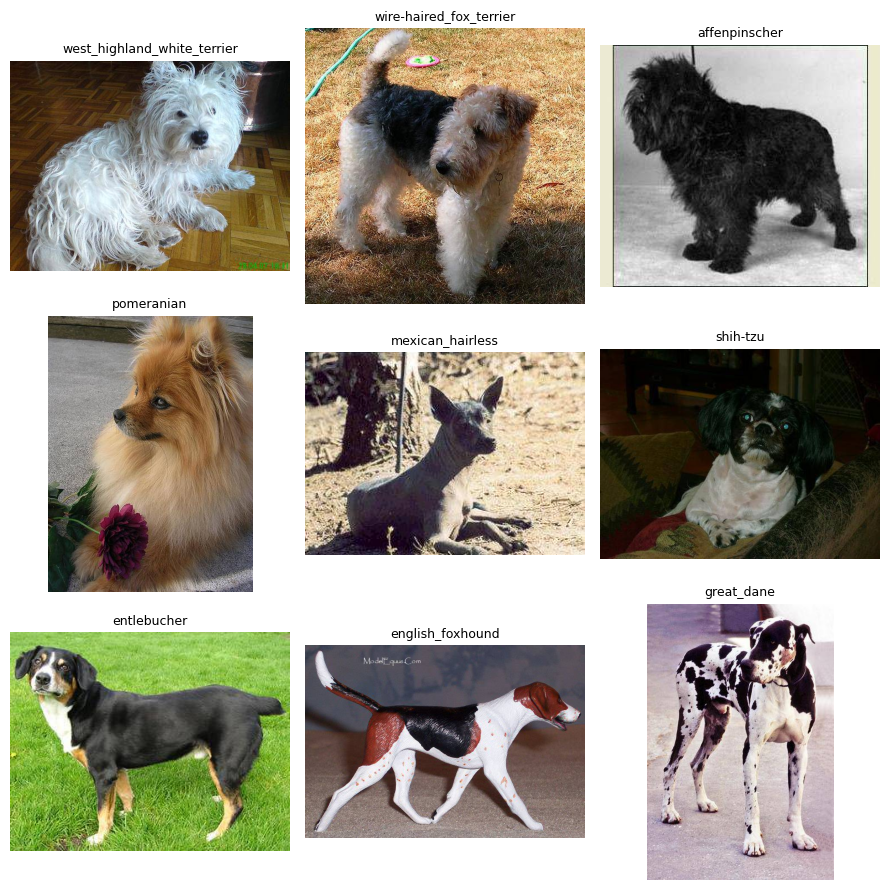

In [ ]:
sample = train_df.sample(9, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(9, 9))
for i, row in sample.iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    breed = class_names[row["y"]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(breed, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

#7 Parametri i augmentacija


##7.1 Podešavanje parametara; augmentacija
Nakon analize skupa podataka, u ovom koraku podešavaju se osnovni parametri koji će se koristiti u daljem radu, kao što su dimenzija ulaznih slika i veličina batch-a tokom treniranja modela.

Pored toga, uvodi se i augmentacija podataka, odnosno primjena jednostavnih transformacija nad slikama iz trening skupa (npr. horizontalno okretanje, blaga rotacija i zumiranje). Na taj način model tokom treniranja vidi različite varijacije istih slika, što može doprinijeti boljoj generalizaciji i otpornosti na promjene u ulaznim podacima.

Nakon definisanja parametara i augmentacije, formira se tf.data pipeline koji automatizuje pripremu slika za model.
U okviru ovog procesa slike se učitavaju sa definisanih putanja, obrađuju (dekodiranje, promjena dimenzija i po potrebi augmentacija), grupišu u batch-eve i pripremaju za efikasnije treniranje i validaciju modela.

##7.2 Definisanje osnovnih parametara i augmentacije
Definišu se osnovni parametri koji će se koristiti u daljoj obradi slika:
- `IMG_SIZE` – definiše dimenziju na koju se svaka slika prilagođava prije ulaska u model (npr. 224x224), kako bi sve ulazne slike imale isti format
- `BATCH_SIZE` – određuje koliko slika se istovremeno obrađuje u jednom koraku treniranja, odnosno koliki broj uzoraka čini jedan batch
- `AUTOTUNE` – TensorFlow opcija za optimizaciju performansi pipeline-a

Takođe se definiše sekvencijalni model za augmentaciju podataka, koji se primjenjuje samo nad trening skupom kako bi se povećala raznolikost ulaznih primjera.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Augmentacija
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name='augmentation')

Definisani parametri i augmentacija predstavljaju osnovu za standardizovanu pripremu slika prije njihovog prosljeđivanja modelu.

##7.3 Funkcija za učitavanje i obradu slike (*decode_and_resize*)

U nastavku se definiše funkcija `decode_and_resize`, koja vrši učitavanje slike sa zadate putanje, dekodiranje JPEG formata, konverziju u float32 format i promjenu dimenzija na zadatu veličinu (`IMG_SIZE`).

Ako je uključena augmentacija (`augment=True`), nad slikom se dodatno primjenjuju transformacije definisane u prethodnom koraku.
Funkcija vraća ili samo sliku (za test podatke), ili par (slika, labela) kada je dostupna oznaka klase.

In [ ]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    img = tf.image.resize(img, img_size)
    if augment:
        img = data_augmentation(img, training=True)
    if label is None:
        return img
    return img, label

Na ovaj način obezbjeđuje se jedinstvena obrada svih ulaznih slika i priprema podataka u formatu koji model može koristiti.

##7.4 Funkcija za kreiranje dataset-a (*build_dataset*)
Funkcija `build_dataset` koristi se za kreiranje `tf.data.Dataset` objekta iz DataFrame-a koji sadrži putanje do slika i numeričke oznake klasa.
Njena svrha je da na jednom mjestu objedini sve korake pripreme podataka, kako bi se isti postupak jednostavno primijenio i na trening i na validacioni skup.

U okviru funkcije najprije se izdvajaju putanje do slika i odgovarajuće labele, a zatim se od njih formira `tf.data.Dataset`.
Ako je u pitanju trening skup, podaci se dodatno miješaju kako bi redoslijed uzoraka bio nasumičan tokom treniranja.

Nakon toga se nad svakim elementom primjenjuje funkcija `decode_and_resize`, koja učitava sliku sa diska, prilagođava je zadatoj dimenziji i, po potrebi, primjenjuje augmentaciju.
Tako obrađeni podaci se zatim grupišu u batch-eve, što omogućava da model obrađuje više slika istovremeno.

Na kraju se koristi `prefetch`, čime se naredni batch priprema unaprijed dok model obrađuje trenutni, što doprinosi efikasnijem i bržem treniranju.


In [ ]:
def build_dataset(df_like, training=True, shuffle=True):
    paths = df_like['filepath'].values
    labels = df_like['y'].values if 'y' in df_like.columns else None
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)) if labels is not None else tf.data.Dataset.from_tensor_slices(paths)

    if training and shuffle:
        ds = ds.shuffle(buffer_size=len(df_like), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: decode_and_resize(p, l, augment=training),
        num_parallel_calls=AUTOTUNE
    ) if labels is not None else ds.map(
        lambda p: decode_and_resize(p, None),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

##7.5 Kreiranje trening i validacionog dataset-a; provjera batch oblika

Nakon definisanja funkcija, formiraju se `train_ds` i `val_ds` skupovi podataka koji će se koristiti u treniranju i validaciji modela.

Za trening skup uključeni su miješanje podataka (`shuffle`) i augmentacija slika, kako bi model tokom treniranja dobijao raznovrsnije primjere i bolje generalizovao.

Za validacioni skup koristi se samo osnovna obrada slika (učitavanje, dekodiranje i promjena dimenzija), bez augmentacije, kako bi evaluacija modela bila realna i konzistentna.

Na kraju se vrši kratka provjera izgleda jednog batch-a, pri čemu se ispisuju dimenzije slika i labela.

In [ ]:
train_ds = build_dataset(train_df, training=True, shuffle=True)
val_ds   = build_dataset(val_df,   training=False, shuffle=False)

for images, labels in train_ds.take(1):
    print("Batch images:", images.shape)
    print("Batch labels:", labels.shape)

Batch images: (32, 224, 224, 3)
Batch labels: (32,)


U narednom koraku pristupa se definisanju arhitekture modela i podešavanju procesa treniranja.

#8 Definisanje modela


##8.1 Definisanje arhitekture modela korišćenjem transfer learning pristupa

U ovom koraku definiše se arhitektura modela za klasifikaciju rasa pasa primjenom **transfer learning** pristupa.

Umjesto treniranja mreže od početka, koristi se prethodno treniran model `EfficientNetB0` sa težinama naučenim na skupu `ImageNet`, što omogućava brže treniranje i bolje performanse, posebno kada se radi sa većim brojem klasa.

##8.2 Funkcija za kreiranje modela
Model se definiše unutar funkcije `build_model`, kako bi se arhitektura mogla jednostavno ponovo kreirati po potrebi.

Kao osnova koristi se `EfficientNetB0` bez završnog klasifikacionog sloja (`include_top=False`), dok se na izlaz baze dodaju slojevi za klasifikaciju prilagođeni broju klasa u dataset-u.

U početnoj fazi treniranja baza modela se zamrzava (`base.trainable = False`), što znači da se treniraju samo novododati završni slojevi.

In [ ]:
def build_model(num_classes, img_size=IMG_SIZE):
    base = applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=img_size + (3,)
    )
    base.trainable = False

    inputs = layers.Input(shape=img_size + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

##8.3 Kreiranje modela i pregled arhitekture

Nakon definisanja funkcije, model se kreira pozivom funkcije `build_model`(`num_classes`), pri čemu se broj izlaznih neurona automatski prilagođava broju klasa u dataset-u.

Zatim se prikazuje pregled arhitekture (`model.summary()`), kako bi se provjerili slojevi modela i ukupan broj parametara.

In [ ]:
model = build_model(num_classes)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##9 Provjera okruženja

Prije pokretanja treniranja modela vrši se provjera dostupnih fizičkih uređaja u **TensorFlow** okruženju, sa fokusom na dostupnost GPU-a.


In [ ]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Ispis prikazuje listu uređaja koje TensorFlow prepoznaje u trenutnom okruženju.

Ako je GPU dostupan, biće prikazan u drugom ispisu.

#10 Početno treniranje modela sa zamrznutom osnovom

Prije pokretanja treniranja definišu se callback funkcije koje služe za praćenje performansi modela i automatsko prilagođavanje procesa treniranja.

Nakon toga se pokreće treniranje modela nad trening skupom (`train_ds`), uz validaciju na skupu `val_ds`.

- `EarlyStopping` – koristi se za automatsko zaustavljanje treniranja kada model više ne pokazuje poboljšanje na validacionom skupu u određenom broju uzastopnih epoha. Na taj način se izbjegava nepotrebno treniranje, a model zadržava najbolje postignute težine
- `ReduceLROnPlateau` – koristi se za automatsko smanjenje stope učenja kada napredak modela na validacionom skupu uspori ili stagnira

In [ ]:
es = callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_accuracy',
    mode='max'
)

rlr = callbacks.ReduceLROnPlateau(
    patience=2,
    factor=0.5,
    monitor='val_accuracy',
    mode='max'
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[es, rlr],
    verbose=1
)

Epoch 1/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 166s 535ms/step - accuracy: 0.0078 - loss: 4.9041 - val_accuracy: 0.0098 - val_loss: 4.8699 - learning_rate: 0.0010
Epoch 2/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 115s 448ms/step - accuracy: 0.0131 - loss: 4.8698 - val_accuracy: 0.0112 - val_loss: 4.8536 - learning_rate: 0.0010
Epoch 3/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 142s 449ms/step - accuracy: 0.0081 - loss: 4.8748 - val_accuracy: 0.0083 - val_loss: 4.8648 - learning_rate: 0.0010
Epoch 4/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 115s 448ms/step - accuracy: 0.0084 - loss: 4.8650 - val_accuracy: 0.0112 - val_loss: 4.8703 - learning_rate: 0.0010
Epoch 5/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 114s 447ms/step - accuracy: 0.0074 - loss: 4.8543 - val_accuracy: 0.0103 - val_loss: 4.8166 - learning_rate: 5.0000e-04
Epoch 6/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 115s 450ms/step - accuracy: 0.0092 - loss: 4.8366 - val_accuracy: 0.0108 - val_loss: 4.8063 - learning_rate: 5.0000e-04
Epoch 7/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 142s 451ms/step 

Tokom treniranja model se optimizuje na trening skupu, dok se nakon svake epohe prati performansa na validacionom skupu.

Rezultati treniranja (vrijednosti funkcije gubitka i metrika po epohama) čuvaju se u objektu hist, koji će se u narednom koraku koristiti za vizuelizaciju toka treniranja i analizu ponašanja modela.

##11 Fino podešavanje modela (*fine-tuning*) odmrzavanjem dijela baze

U ovom koraku započinje druga faza treniranja modela (fine-tuning).

Za razliku od prve faze, gdje je osnova bila zamrznuta i trenirani su samo završni slojevi, sada se otključava dio slojeva baze modela kako bi se mreža dodatno prilagodila konkretnom zadatku klasifikacije rasa pasa.

Najprije se iz postojeće arhitekture izdvaja `base_model`, a zatim se slojevi od `unfreeze_from` do kraja baze postavljaju kao trenabilni (`trainable=True`).

Na taj način se ne mijenja cijela mreža odjednom, već samo njen dublji dio, što omogućava kontrolisanije i stabilnije prilagođavanje modela.

Nakon toga se model ponovo kompajlira sa manjom stopom učenja, jer su u ovoj fazi potrebne manje i pažljivije promjene težina.

Na kraju se pokreće nastavak treniranja nad istim trening i validacionim skupom, kako bi se provjerilo da li djelimično odmrzavanje baze doprinosi poboljšanju performansi modela.


In [ ]:
unfreeze_from = 120  # promijeniti po potrebi
base_model = model.layers[1]

for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[es, rlr],
    verbose=1
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 200s 607ms/step - accuracy: 0.0109 - loss: 4.8377 - val_accuracy: 0.0132 - val_loss: 4.8123 - learning_rate: 1.0000e-04
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 486ms/step - accuracy: 0.0205 - loss: 4.7060 - val_accuracy: 0.0313 - val_loss: 4.6273 - learning_rate: 1.0000e-04
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 482ms/step - accuracy: 0.0370 - loss: 4.5431 - val_accuracy: 0.0181 - val_loss: 4.7676 - learning_rate: 1.0000e-04
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 490ms/step - accuracy: 0.0480 - loss: 4.3808 - val_accuracy: 0.0249 - val_loss: 4.7408 - learning_rate: 1.0000e-04
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 141s 485ms/step - accuracy: 0.0740 - loss: 4.2148 - val_accuracy: 0.0254 - val_loss: 4.6581 - learning_rate: 5.0000e-05
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 127s 495ms/step - accuracy: 0.0818 - loss: 4.1110 - val_accuracy: 0.0259 - val_loss: 4.6274 - learning_rate: 5.0000e-05
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 

U ovoj fazi model nastavlja treniranje uz djelimično odmrzavanje trenirane baze, čime se omogućava dodatno prilagođavanje naučenih karakteristika konkretnom dataset-u.

Rezultati ove faze treniranja čuvaju se u hist2 i mogu se uporediti sa rezultatima prve faze kako bi se procijenio efekat fine-tuning pristupa.

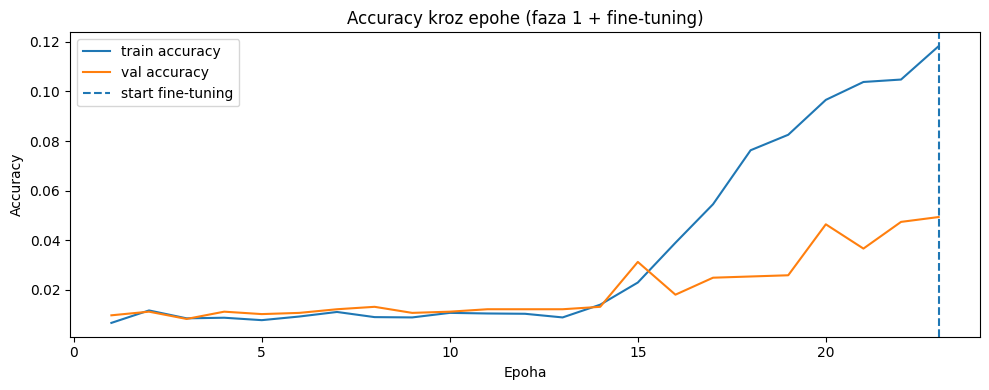

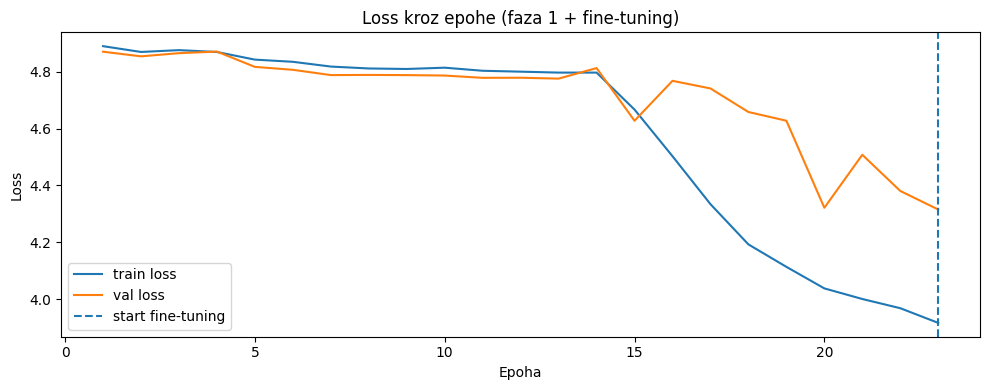

In [ ]:
def plot_histories(h1, h2=None):
    acc = h1.history.get("accuracy", [])
    val_acc = h1.history.get("val_accuracy", [])
    loss = h1.history.get("loss", [])
    val_loss = h1.history.get("val_loss", [])

    if h2 is not None:
        acc += h2.history.get("accuracy", [])
        val_acc += h2.history.get("val_accuracy", [])
        loss += h2.history.get("loss", [])
        val_loss += h2.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)
    fine_tune_start = len(h1.history.get("accuracy", []))  # granica između faza

    # Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, acc, label="train accuracy")
    plt.plot(epochs, val_acc, label="val accuracy")
    if h2 is not None:
        plt.axvline(x=fine_tune_start, linestyle="--", label="start fine-tuning")
    plt.title("Accuracy kroz epohe (faza 1 + fine-tuning)")
    plt.xlabel("Epoha")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss, label="train loss")
    plt.plot(epochs, val_loss, label="val loss")
    if h2 is not None:
        plt.axvline(x=fine_tune_start, linestyle="--", label="start fine-tuning")
    plt.title("Loss kroz epohe (faza 1 + fine-tuning)")
    plt.xlabel("Epoha")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_histories(hist, hist2)

##12 Evaluacija na validacionom skupu

Nakon završetka treniranja i **fine-tuning** faze, vrši se evaluacija modela na validacionom skupu kako bi se procijenila njegova sposobnost klasifikacije na podacima koje nije koristio za direktno učenje.

U ovom koraku model generiše predikcije za slike iz validacionog skupa, nakon čega se rezultati upoređuju sa stvarnim klasama.

U ovom koraku najprije se izdvajaju stvarne oznake klasa iz validacionog skupa (`y_val_true`).

Zatim model generiše vjerovatnoće pripadnosti svakoj klasi (`y_val_proba`), a konačna predikcija (`y_val_pred`) dobija se izborom klase sa najvećom vjerovatnoćom, primjenom funkcije `argmax`.

Za evaluaciju performansi koriste se classification report i matrica konfuzije.

Klasifikacioni izvještaj daje detaljan pregled performansi modela po klasama kroz metrike kao što su precision, recall i F1-score, dok matrica konfuzije omogućava uvid u raspored tačnih i pogrešnih predikcija, odnosno uvid u to koje se klase najčešće međusobno miješaju.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        16
           1     0.0231    0.6957    0.0448        23
           2     0.0707    0.4118    0.1207        17
           3     0.0000    0.0000    0.0000        22
           4     0.0000    0.0000    0.0000        15
           5     0.0000    0.0000    0.0000        16
           6     0.0909    0.0476    0.0625        21
           7     0.1786    0.2273    0.2000        22
           8     0.0000    0.0000    0.0000        16
           9     0.1667    0.0476    0.0741        21
          10     0.0714    0.0556    0.0625        18
          11     0.5000    0.0435    0.0800        23
          12     0.1250    0.0667    0.0870        15
          13     0.2727    0.2857    0.2791        21
          14     0.0000    0.0000    0.0000        17
          15     0.0000    0.0000    0.0000        17
          16     0.0000    0.0000    0.0000        14
          17     0.0000    

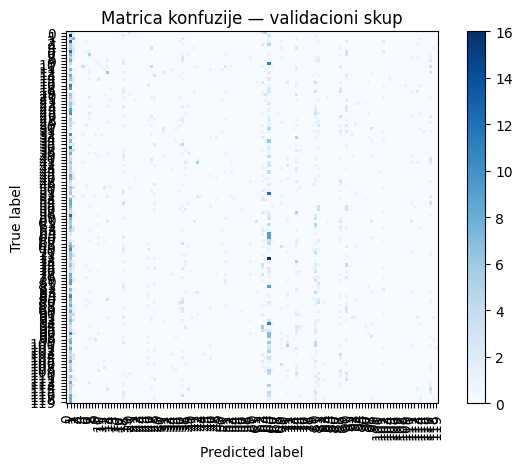

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_val_true = val_df['y'].values
y_val_proba = model.predict(val_ds, verbose=0)
y_val_pred  = np.argmax(y_val_proba, axis=1)

print(classification_report(y_val_true, y_val_pred, digits=4))

cm = confusion_matrix(y_val_true, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot(include_values=False, xticks_rotation=90, cmap='Blues')
plt.title("Matrica konfuzije — validacioni skup")
plt.tight_layout()
plt.show()

## 13 Stratifikovana K-fold validacija

Pored standardne evaluacije na jednom validacionom skupu, model se može dodatno procijeniti primjenom stratifikovane K-fold unakrsne validacije.

U ovom pristupu skup podataka se dijeli na više dijelova, pri čemu se u svakom dijelu približno zadržava raspodjela klasa. Model se zatim trenira i evaluira više puta, tako da svaki dio podataka u jednom trenutku bude korišćen za validaciju.

Najprije se definišu osnovni parametri, kao što su broj podjela skupa podataka (`N_SPLITS`) i broj epoha treniranja po svakoj podjeli (`EPOCHS_FOLD`), dok se pomoću opcije `DO_KFOLD` određuje da li će se ovaj postupak zaista pokrenuti.

Zatim se primjenjuje `StratifiedKFold`, kojim se skup podataka dijeli na više dijelova uz očuvanje približno iste raspodjele klasa u svakom dijelu.
U svakoj iteraciji jedan dio podataka koristi se za validaciju, a preostali dio za treniranje, čime se dobija više različitih procjena performansi modela.

Za svaki ciklus model se ponovo kreira i trenira, nakon čega se vrši evaluacija i iz klasifikacionog izvještaja izdvajaju vrijednosti `F1 macro` i `F1 weighted` mjere.
Dobijeni rezultati se čuvaju za sve cikluse, a na kraju se računa njihova prosječna vrijednost.

Za ozbiljnije ocene stabilnosti, možete pokrenuti K-Fold trening. Ovo je **template** — podesite `N_SPLITS` i `EPOCHS` skromno (npr. 3–5), jer je vreme treninga proporcionalno broju foldova.

In [ ]:
N_SPLITS = 5
EPOCHS_FOLD = 5  # smanjiti po potrebi
DO_KFOLD = False  # postavite na True ako zaista želite da pokrenete

cv_histories = []
cv_scores = []

if DO_KFOLD:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    X_all = df['filepath'].values
    y_all = df['y'].values

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_all, y_all), 1):
        print(f"\n===== FOLD {fold}/{N_SPLITS} =====")

        # Formiranje trening i validacionog skupa
        tr_df = pd.DataFrame({'filepath': X_all[tr_idx], 'y': y_all[tr_idx]})
        va_df = pd.DataFrame({'filepath': X_all[va_idx], 'y': y_all[va_idx]})

        # Kreiranje tf.data skupova
        tr_ds = build_dataset(tr_df, training=True,  shuffle=True)
        va_ds = build_dataset(va_df, training=False, shuffle=False)

        # Novi model za svaki fold
        m = build_model(num_classes)

        # Callback funkcije (praćenje validacione tačnosti)
        es = callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy', mode='max')
        rlr = callbacks.ReduceLROnPlateau(patience=1, factor=0.5, monitor='val_accuracy', mode='max')

        # Treniranje
        h = m.fit(tr_ds, validation_data=va_ds, epochs=EPOCHS_FOLD, callbacks=[es, rlr], verbose=1)
        cv_histories.append(h.history)

        # Ocjena
        y_va_true = va_df['y'].values
        y_va_pred = np.argmax(m.predict(va_ds, verbose=0), axis=1)
        rep = classification_report(y_va_true, y_va_pred, output_dict=True, zero_division=0)
        f1m = rep['macro avg']['f1-score']; f1w = rep['weighted avg']['f1-score']
        print(f"Fold {fold} — F1 macro: {f1m:.4f} | F1 weighted: {f1w:.4f}")
        cv_scores.append((f1m, f1w))

    print("\nCV rezultati (F1 macro, weighted):", cv_scores)
    print("Prosek F1 macro:", np.mean([s[0] for s in cv_scores]))

## 14 Inference na test skupu i submission

U završnom koraku projekta model se koristi za generisanje predikcija nad slikama iz test skupa.

Najprije se učitavaju putanje do test slika, zatim se nad njima formira tf.data pipeline sa istom osnovnom obradom slika, ali bez augmentacije.

Nakon toga model računa predikcije za test skup, a dobijene numeričke oznake klasa prevode se nazad u tekstualne nazive rasa pasa pomoću objekta `LabelEncoder`.

Pošto dataset sadrži fajl `sample_submission.csv`, on se koristi kao šablon za formiranje izlaznog fajla. Na kraju se kreira i snima fajl `submission.csv`, koji sadrži identifikatore slika i odgovarajuće predikovane klase.

In [ ]:
# Učitavanje putanja do test slika
test_files = sorted([str(p) for p in TEST_DIR.glob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.webp']])
print("Broj test slika:", len(test_files))

test_ds = tf.data.Dataset.from_tensor_slices(test_files)
test_ds = test_ds.map(lambda p: tf.image.resize(tf.image.convert_image_dtype(tf.image.decode_jpeg(tf.io.read_file(p), channels=3), tf.float32), IMG_SIZE), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_proba = model.predict(test_ds, verbose=0)
test_pred  = np.argmax(test_proba, axis=1)
test_labels= le.inverse_transform(test_pred)

sub = pd.read_csv(SUB_TPL)
    # heuristike za kolone
cols = [c.lower() for c in sub.columns]
    # pokušaj da pronađe kolonu koja liči na id/filename
if 'id' in cols:
      id_col = sub.columns[cols.index('id')]
elif 'filename' in cols:
      id_col = sub.columns[cols.index('filename')]
else:
      id_col = sub.columns[0]
    # mapiraj redosled po imenu fajla prisutnom u sub
    # uklanjamo eventualne putanje
base_names = [os.path.basename(x) for x in test_files]
df_test = pd.DataFrame({id_col: base_names, 'predicted': test_labels})
    # ako sub ima drugu kolonu za labelu, preimenuj
if len(sub.columns) >= 2:
    label_col = sub.columns[-1]
else:
    label_col = 'label'
    sub[label_col] = ''
out = sub[[id_col]].merge(df_test, on=id_col, how='left')
out = out.rename(columns={'predicted': label_col})

OUT_CSV = 'submission.csv'
out.to_csv(OUT_CSV, index=False)
print("Sačuvano:", OUT_CSV)

Broj test slika: 10202
Sačuvano: submission.csv


Nakon izvršavanja ovog koraka formiran je fajl `submission.csv` sa predikcijama modela za test skup, u formatu usklađenom sa šablonom `sample_submission.csv`.

##15 Demonstracija rada modela na validacionom skupu
U nastavku je prikazan primjer predikcija modela na validacionom skupu. Nasumično se uzima jedan batch slika iz validacionog skupa, te se za svaku sliku prikazuje stvarna (True) i predviđena (Predicted) klasa.

Ovakav prikaz omogućava intuitivan uvid u ponašanje modela i pokazuje u kojim slučajevima model donosi tačne odluke, a gdje dolazi do grešaka, naročito kod vizuelno sličnih rasa.



Batch accuracy: 0.0625


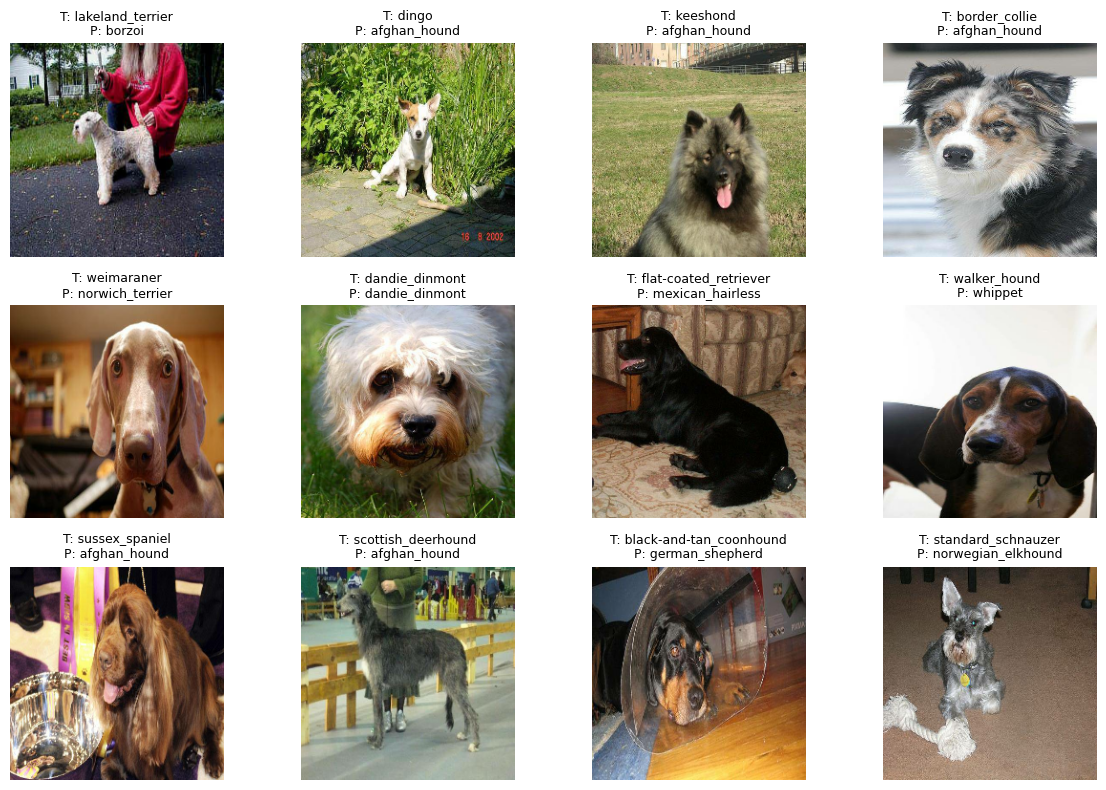

In [ ]:
x_batch, y_batch = next(iter(val_ds))

proba = model.predict(x_batch, verbose=0)
pred = np.argmax(proba, axis=1)

acc_batch = (pred == y_batch.numpy()).mean()
print("Batch accuracy:", acc_batch)

n_show = min(12, x_batch.shape[0])
plt.figure(figsize=(12, 8))
for i in range(n_show):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_batch[i].numpy())
    t = int(y_batch[i].numpy())
    p = int(pred[i])
    plt.title(f"T: {class_names[t]}\nP: {class_names[p]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

##16 Čuvanje artefakata

U cilju dokumentovanja rezultata i omogućavanja ponovne upotrebe modela, sačuvani su ključni artefakti u folder artefacts/.

Sačuvani su sljedeći elementi:
- model.keras - trenirani model u Keras formatu, koji omogućava ponovno učitavanje i korišćenje bez potrebe za ponovnim treniranjem
- classification_report.txt - detaljan prikaz metrika (precision, recall, F1-score) po klasama na validacionom skupu
- confusion_matrix.png - vizuelni prikaz matrice konfuzije, koji omogućava uvid u to koje klase se najčešće međusobno miješaju

Ovim je kompletiran proces treniranja i evaluacije modela do čuvanja rezultata, čime je omogućena dalja analiza modela bez ponovnog izvođenja cijelog postupka.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


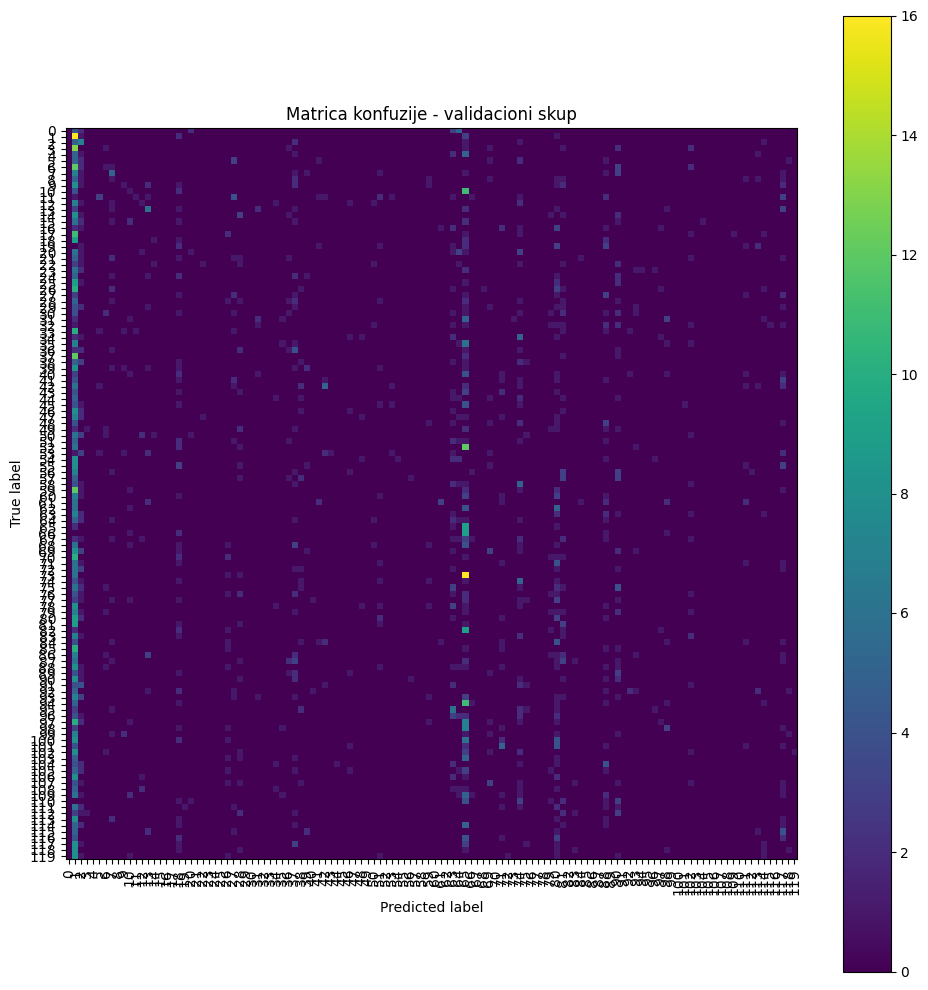

U artifacts/ je sačuvano: model.keras, classification_report.txt, confusion_matrix.png


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#pravljenje artifacts/
os.makedirs("artifacts", exist_ok=True)

#čuvanje modela
model.save("artifacts/model.keras")

#čuvanje classification report
rep = classification_report(y_val_true, y_val_pred, digits=4)
with open ("artifacts/classification_report.txt", "w", encoding="utf-8") as f: f.write(rep)

#čuvanje confusion matrix kao sliku
cm= confusion_matrix(y_val_true, y_val_pred)
disp= ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(include_values=False, xticks_rotation=90, ax=ax)
plt.title("Matrica konfuzije - validacioni skup")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=200)
plt.show()

print("U artifacts/ je sačuvano: model.keras, classification_report.txt, confusion_matrix.png")

In [ ]:
with open("artifacts/README.md", "w", encoding="utf-8") as f:
    f.write("Sve je sačuvano u ovom folderu")

print("README je dodat u artifacts/")

README je dodat u artifacts/


# ZAKLJUČAK

U ovom projektu implementiran je sistem za klasifikaciju rasa pasa na osnovu fotografija, koristeći duboko učenje i transfer learning pristup. Zadatak je višeklasna klasifikacija sa ukupno 120 različitih rasa, što je zahtjevno zbog velike sličnosti između pojedinih pasmina, ali i zbog varijacija u osvjetljenju, pozadini, poziciji psa i kvalitetu fotografije. Pored toga, ovakav problem je osjetljiv i na raspodjelu podataka — ako su neke rase slabije zastupljene, model te klase teže uči i češće ih miješa sa sličnijim i zastupljenijim rasama.

Kao osnova korišćen je `EfficientNetB0` model treniran na `ImageNet` skupu, što omogućava da se već naučene vizuelne reprezentacije iskoriste kao početna tačka. Trening je realizovan u dvije faze: u prvoj fazi trenirani su dodati klasifikacioni slojevi dok je bazni model bio zamrznut, a zatim je primijenjen fine-tuning dijela baznog modela uz manju stopu učenja. Ovaj pristup je standardan u transfer learning scenarijima i omogućava stabilnije učenje bez treniranja modela od nule.

Evaluacija modela izvedena je na validacionom skupu korišćenjem metrike `accuracy`, kao i detaljnijom analizom kroz `classification report` i `matricu konfuzije`. Rezultati pokazuju da model ostvaruje određeni nivo učenja, ali da ukupne performanse nisu dovoljno visoke da bi se moglo reći da pouzdano razlikuje sve rase. Greške su posebno izražene kod vizuelno sličnih pasmina, gdje se model često “dvoumi”, kao i kod klasa koje imaju manje primjera ili veće varijacije u izgledu. Vizuelna demonstracija predikcija dodatno potvrđuje da model u nekim slučajevima daje tačne klasifikacije, ali da stabilnost predikcija varira, što je očekivano za problem sa velikim brojem klasa i složenim uslovima snimanja.

U praktičnom dijelu projekta značajan fokus je bio na pravilnoj pripremi podataka: formiran je `tf.data pipeline`, izvršena je normalizacija slika i primijenjena augmentacija kako bi se povećala raznovrsnost trening skupa. Korišćeni su i callback mehanizmi (`EarlyStopping` i `ReduceLROnPlateau`) kako bi se trening stabilizovao i smanjio rizik od pretreniranosti. Na kraju je generisan submission.csv fajl u traženom formatu, čime je kompletiran cijeli tok od učitavanja podataka do dobijanja predikcija.

Projekat je demonstrirao kompletan proces izgradnje CNN rješenja za klasifikaciju slika: obradu i pripremu podataka, primjenu transfer learning-a, treniranje u više faza, evaluaciju i generisanje izlaznih predikcija. Potencijalna poboljšanja uključuju: treniranje snažnije arhitekture (npr. `EfficientNetB2/B3`), pažljiviji fine-tuning uz manji learning rate i više epoha, balansiranje klasa (class weights ili oversampling), kao i test-time augmentaciju ili ensembling pristup. Dodatno, uvođenje top-k metrika (npr. top-5 accuracy) može dati realniji uvid u performanse kod problema sa velikim brojem klasa, gdje je često važno da se tačan odgovor nalazi među nekoliko najboljih predikcija.

Na osnovu svega navedenog može se zaključiti da transfer learning predstavlja dobar početni pristup za ovakve probleme, ali da kod zadataka sa velikim brojem vizuelno sličnih klasa kvalitet rješenja u velikoj mjeri zavisi od količine i ravnomjernosti podataka, kao i od dubine fine-tuning procesa i izbora jače arhitekture.

#LITERATURA

Materijali koji su korišćeni kao pomoć prilikom izrade projektnog zadataka su:
- Materijali sa vježbi
- Tan, M., Le, Q. (2019) - EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. Proceedings of ICML
- TensorFlow – Transfer Learning Tutorial
https://www.tensorflow.org/tutorials/images/transfer_learning
- Shorten, C., Khoshgoftaar, T. (2019). - A survey on Image Data Augmentation for Deep Learning. Journal of Big Data.